In [61]:
# Importiere Bibliotheken - das sind Werkzeugkästen mit vordefinierten Funktionen
import pandas as pd  # pandas: Arbeitet mit Daten in Tabellen (DataFrames)
import matplotlib.pyplot as plt  # matplotlib: Erstellt Diagramme und Grafiken
import matplotlib.dates as mdates  # mdates: Formatiert Datum/Zeit-Achsen in Plots
from functools import lru_cache  # lru_cache: Speichert Funktionsergebnisse (vermeidet wiederholte API-Aufrufe)
from entsoe import EntsoePandasClient  # EntsoePandasClient: Verbindung zur ENTSO-E Stromdaten-API

In [62]:
# Authentifizierung: Dein persönlicher Schlüssel für die ENTSO-E API
API_TOKEN = "9af21e20-861e-41a0-873b-03c15cddf7c9"
# Erstelle einen Client (die Verbindung zur ENTSO-E Datenbank)
client = EntsoePandasClient(api_key=API_TOKEN)

In [63]:
# @lru_cache: Speichert Ergebnisse von Funktionsaufrufen (bei gleichen Eingaben = schneller)
@lru_cache(maxsize=None)
def hole_lastdaten(client, art, kuerzel, start_iso, end_iso):
    """Allgemeine Funktion zum Abrufen von Stromdaten von der ENTSO-E API"""
    # Konvertiere ISO-String-Zeitstempel zurück zu Timestamp-Objekten
    start = pd.Timestamp(start_iso)
    end = pd.Timestamp(end_iso)
    
    # Je nach 'art' Parameter: hole Last oder Erzeugungsdaten
    if art == "load":
        return client.query_load(kuerzel, start=start, end=end)  # Stromlast in MW
    if art == "generation":
        return client.query_generation(kuerzel, start=start, end=end)  # Stromerzeugung in MW
    raise ValueError(f"Unbekannte Abfrageart: {art}")

# Vereinfachte Wrapper-Funktionen für Last- und Erzeugungsdaten
def hole_load_daten(client, kuerzel, start, end):
    """Ruft Lastdaten auf - konvertiert Timestamps zu ISO-Strings für Caching"""
    return hole_lastdaten(client, "load", kuerzel, start.isoformat(), end.isoformat())

def hole_generation_daten(client, kuerzel, start, end):
    """Ruft Erzeugungsdaten auf - konvertiert Timestamps zu ISO-Strings für Caching"""
    return hole_lastdaten(client, "generation", kuerzel, start.isoformat(), end.isoformat())

In [64]:
# Dictionary mit Ländern und ihren ENTSO-E Kürzeln
laender = {
    "Deutschland": "DE",  # Länder-Name -> ENTSO-E Code
    "Frankreich":  "FR",
    #"Spanien":     "ES",  # Mit # auskommentiert = wird nicht ausgeführt
    #"Italien":     "IT",
    #"Polen":       "PL",
    #"Norwegen":    "NO",
    #"Kroatien":    "HR"
}

# Zeitraum für historische Daten: 1. Jan 2023 bis 1. Jan 2024
start = pd.Timestamp("2023-01-01", tz="UTC")  # tz="UTC" = Zeitzone UTC (koordinierte Weltzeit)
end   = pd.Timestamp("2024-01-01", tz="UTC")

In [65]:
# Speichere die Gesamtlast pro Land in 2023
jahresdaten = {}  # Leeres Dictionary für die Ergebnisse

# Schleife über alle Länder in unserem Dictionary
for land, kuerzel in laender.items():  # land = "Deutschland", kuerzel = "DE" usw.
    try:  # Versuche, Daten abzurufen - falls Fehler: gehe zu except
        # Hole Lastdaten vom ENTSO-E Server für das ganze Jahr
        daten = hole_load_daten(client, kuerzel, start, end)
        # Addiere alle Messwerte zusammen (Summe des ganzen Jahres in MWh)
        gesamt = daten.sum()
        # Falls gesamt ein Objekt mit .item()-Methode ist: konvertiere zu Zahl
        if hasattr(gesamt, 'item'):
            gesamt = gesamt.item()
        # Speichere in TWh (teile durch 1 Million MW -> TWh)
        jahresdaten[land] = gesamt / 1_000_000
        # Gib Erfolgsmeldung aus
        print(f"{land}: {jahresdaten[land]:.2f} TWh")
    except Exception as e:  # Falls ein Fehler auftritt:
        # Gib Fehlermeldung aus (z.B. kein Internet, falscher Code)
        print(f"{land}: Fehler – {e}")

Deutschland: 1833.53 TWh
Frankreich: 425.45 TWh


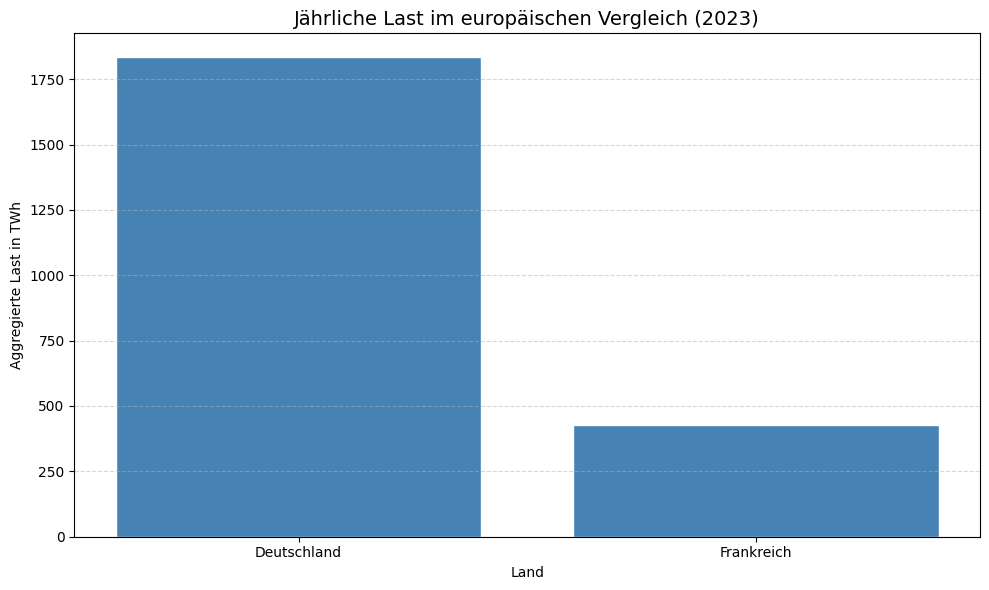

In [66]:
# Konvertiere Dictionary zu DataFrame (Tabelle) für bessere Visualisierung
df = pd.DataFrame.from_dict(jahresdaten, orient="index", columns=["TWh"])
# Sortiere die Länder nach Laststärke (höchste oben)
df = df.sort_values("TWh", ascending=False)

# Erstelle ein Diagramm
fig, ax = plt.subplots(figsize=(10, 6))  # fig = die gesamte Figur, ax = die Achse zum Zeichnen

# Zeichne Balkendiagramm
ax.bar(df.index, df["TWh"], color="steelblue", edgecolor="white")

# Beschriftungen für das Diagramm
ax.set_title("Jährliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Land")  # X-Achse (horizontal)
ax.set_ylabel("Aggregierte Last in TWh")  # Y-Achse (vertikal)
ax.grid(axis="y", linestyle="--", alpha=0.5)  # Gitternetz im Hintergrund

# Speichere und zeige das Diagramm
plt.tight_layout()  # Passe Abstände automatisch an
plt.savefig("lastvergleich_2023.png")  # Speichere als Bilddatei
plt.show()  # Zeige das Diagramm an

In [67]:
# Hole monatliche Daten für jedes Land
monatsdaten = {}  # Dictionary für die Monatsdaten

for land, kuerzel in laender.items():  # Schleife über alle Länder
    try:
        # Hole Lastdaten für das ganze Jahr
        daten = hole_load_daten(client, kuerzel, start, end)
        # Aggregiere auf Monate: "MS" = Monatsanfang, .sum() = summiere alle Werte pro Monat
        # Teile durch 1 Mio um MW zu TWh zu konvertieren
        monatlich = daten.resample("MS").sum() / 1_000_000  # TWh
        # Falls die Daten ein DataFrame sind, squeeze (konvertiere zu Series)
        if hasattr(monatlich, 'squeeze'):
            monatlich = monatlich.squeeze()
        monatsdaten[land] = monatlich
        print(f"{land}: Daten geladen ✅")
    except Exception as e:
        print(f"{land}: Fehler – {e}")

# Alle Länder in einen großen DataFrame zusammenfügen (Tabelle)
df_monate = pd.concat(monatsdaten, axis=1)  # axis=1 = nebeneinander (Länder sind Spalten)
df_monate.columns = monatsdaten.keys()  # Setze Spaltennamen auf Ländernamen
df_monate = df_monate.sort_index()  # Sortiere nach Datum
df_monate = df_monate[df_monate.index.year == 2023]  # Filtere nur 2023
df_monate.index = df_monate.index.strftime("%m.%Y")  # Formatiere Datum zu "MM.YYYY" (z.B. "01.2023")
df_monate = df_monate.round(2)  # Runde auf 2 Dezimalstellen
print(df_monate)  # Zeige die Tabelle

Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅
         Deutschland  Frankreich
01.2023       152.55       40.67
02.2023       163.51       39.29
03.2023       144.62       33.87
04.2023       145.29       30.46
05.2023       141.90       30.02
06.2023       145.01       31.29
07.2023       145.23       29.93
08.2023       143.25       30.55
09.2023       155.18       32.22
10.2023       164.36       38.14
11.2023       164.00       42.98
12.2023         0.16        0.05


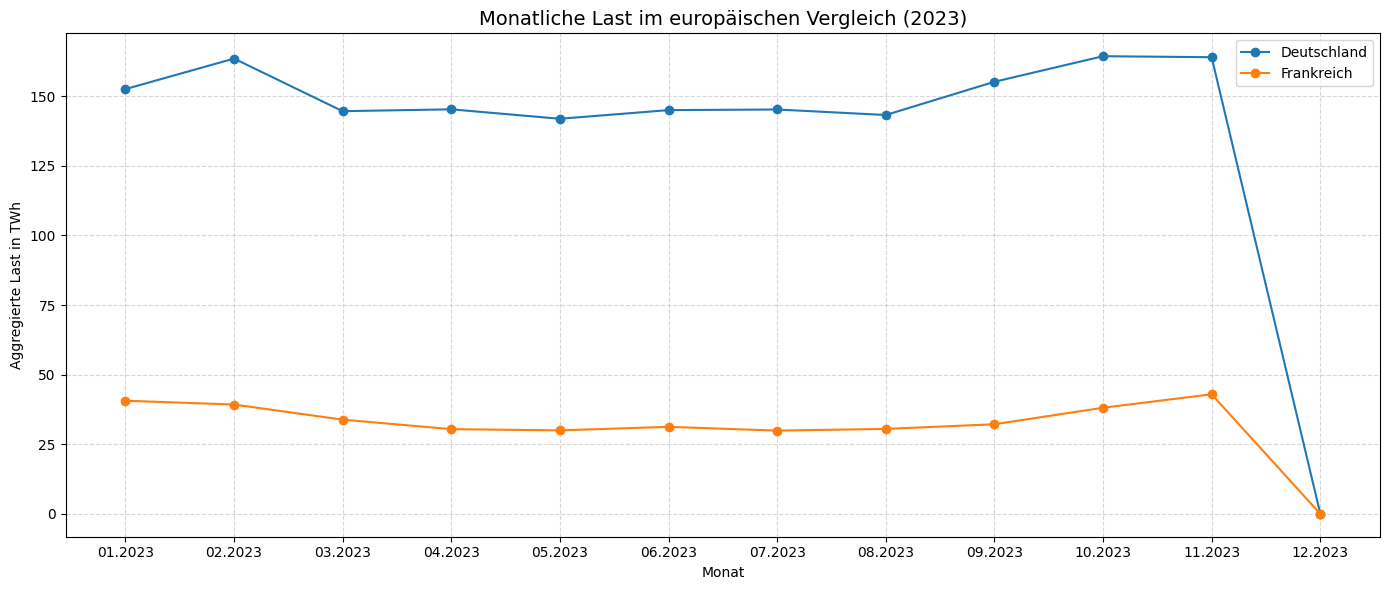

In [68]:
fig, ax = plt.subplots(figsize=(14, 6))

for land in df_monate.columns:
    ax.plot(df_monate.index, df_monate[land], marker="o", label=land)

ax.set_title("Monatliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Aggregierte Last in TWh")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("lastgang_linien_2023.png")
plt.show()

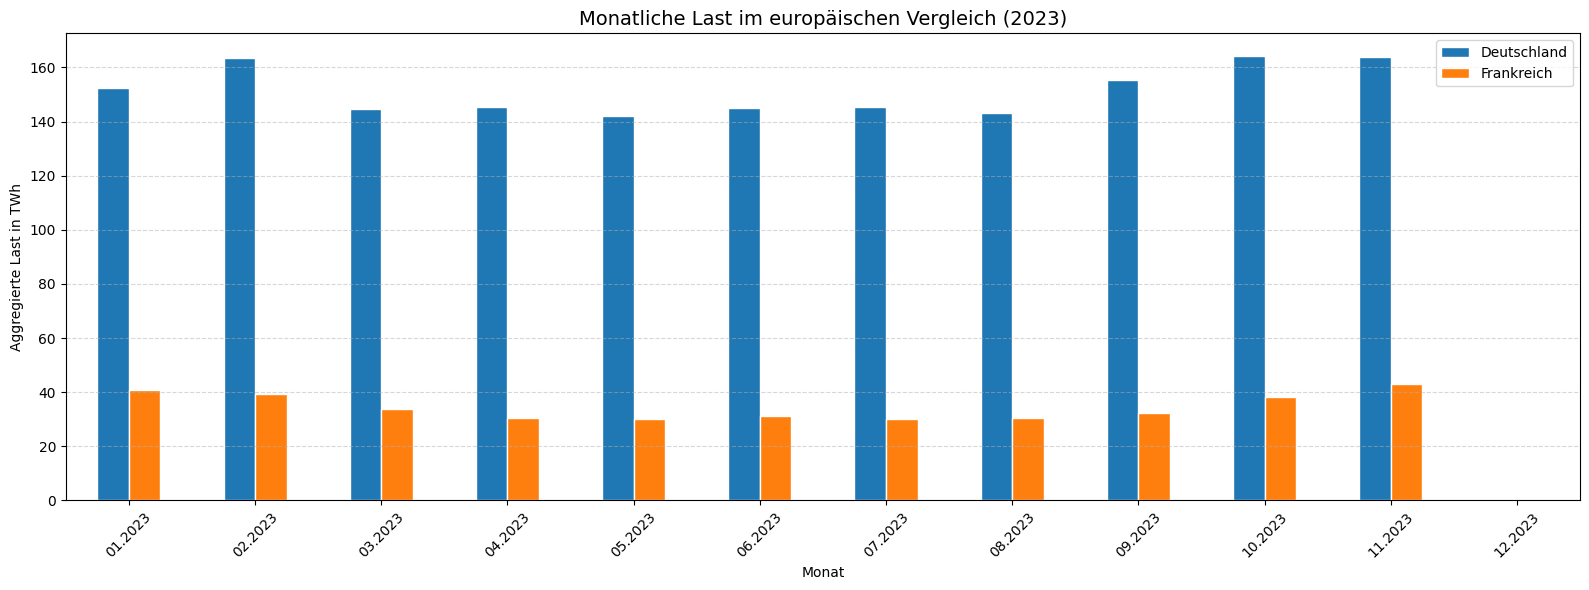

In [69]:
fig, ax = plt.subplots(figsize=(16, 6))

df_monate.plot(kind="bar", ax=ax, edgecolor="white")

ax.set_title("Monatliche Last im europäischen Vergleich (2023)", fontsize=14)
ax.set_xlabel("Monat")
ax.set_ylabel("Aggregierte Last in TWh")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("lastgang_balken_2023.png")
plt.show()

In [70]:
# Funktion: Lade Jahresdaten für beliebiges Jahr
def lade_jahresdaten(client, laender, jahr):
    """
    Lädt monatliche Lastdaten für alle Länder eines bestimmten Jahres.
    Parameter: client (API-Verbindung), laender (Dict), jahr (z.B. 2023)
    Rückgabe: DataFrame mit Monaten als Zeilen und Ländern als Spalten
    """
    # Definiere Zeitraum: vom 1. Januar bis zum 1. Januar des nächsten Jahres
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")
    
    monatsdaten = {}
    for land, kuerzel in laender.items():
        try:
            # Hole Lastdaten für das ganze Jahr
            daten = hole_load_daten(client, kuerzel, start, end)
            # Aggregiere auf Monatssummen und konvertiere zu TWh
            monatlich = daten.resample("MS").sum() / 1_000_000
            # Konvertiere zu Series wenn nötig (pandas Kompatibilität)
            if hasattr(monatlich, 'squeeze'):
                monatlich = monatlich.squeeze()
            monatsdaten[land] = monatlich
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")
    
    # Füge alle Länder in eine Tabelle zusammen
    df = pd.concat(monatsdaten, axis=1)
    df.columns = monatsdaten.keys()
    df = df.sort_index()  # Sortiere nach Datum (chronologisch)
    df = df[df.index.year == jahr]  # Filtere nur das gewünschte Jahr
    df.index = df.index.strftime("%m.%Y")  # Formatiere Datum (z.B. "01.2023")
    df = df.round(2)  # Runde auf 2 Dezimalstellen
    return df  # Gebe die fertige Tabelle zurück

In [71]:
# Lade Daten für die drei Jahre 2023, 2024 und 2025
print("=== 2023 ===")
df_2023 = lade_jahresdaten(client, laender, 2023)  # Rufe Funktion mit Jahr 2023 auf

print("\n=== 2024 ===")
df_2024 = lade_jahresdaten(client, laender, 2024)  # Rufe Funktion mit Jahr 2024 auf

print("\n=== 2025 ===")
df_2025 = lade_jahresdaten(client, laender, 2025)  # Rufe Funktion mit Jahr 2025 auf

=== 2023 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== 2024 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== 2025 ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


In [ ]:
# Importiere os für Dateiverwaltung (Ordner erstellen)
import os

# Erstelle Dictionary mit Jahr als Schlüssel und Daten als Wert
jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

# Schleife: Erstelle für jedes Jahr einen separaten Linienplot
for jahr, df in jahre_dict.items():  # jahr = "2023" usw., df = die zugehörigen Daten
    # Erstelle Ordner mit Jahresname, jetzt mit Prefix "Diagramme_"
    os.makedirs(f"Diagramme_{jahr}", exist_ok=True)
    
    # Erstelle neue Figur und Achse für das Diagramm
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Zeichne für jedes Land eine eigene Linie
    for land in df.columns:  # Schleife über alle Ländernamen (Spaltennamen)
        ax.plot(df.index, df[land], marker="o", label=land)  # marker="o" = Punkte an Datenpunkten
    
    # Beschriftungen
    ax.set_title(f"Monatliche Last {jahr}", fontsize=13)
    ax.set_xlabel("Monat")
    ax.set_ylabel("Last in TWh")
    ax.legend()  # Zeige Legende mit Ländernamen
    ax.grid(linestyle="--", alpha=0.5)  # Gitternetz im Hintergrund
    ax.tick_params(axis='x', rotation=45)  # Drehe X-Achsen-Labels um 45°
    
    plt.suptitle(f"Monatliche Last im europäischen Vergleich ({jahr})", fontsize=14)
    plt.tight_layout()  # Passe Abstände an
    plt.savefig(f"Diagramme_{jahr}/lastgang.png")  # Speichere im neuen Ordner
    plt.close()  # Schließe Figur (gibt Speicher frei)

print("✅ Linienplots für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Linienplots für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [ ]:
# Dictionary mit den drei Jahren
jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

# Schleife: Erstelle für jedes Jahr ein separates Balkendiagramm
for jahr, df in jahre_dict.items():
    # Erstelle Ordner für das Jahr mit Prefix "Diagramme_"
    os.makedirs(f"Diagramme_{jahr}", exist_ok=True)
    
    # Erstelle neue Figur
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Zeichne Balkendiagramm (Balken = bar)
    df.plot(kind="bar", ax=ax, edgecolor="white")  # kind="bar" = Balkendiagramm
    ax.set_title(f"Monatliche Last {jahr}", fontsize=13)
    ax.set_xlabel("Monat")
    ax.set_ylabel("Last in TWh")
    ax.grid(axis="y", linestyle="--", alpha=0.5)  # Nur Y-Achsen Gitternetz
    ax.tick_params(axis='x', rotation=45)  # Drehe X-Labels
    ax.legend(fontsize=9)  # Ländernamen-Legende (kleiner Font)
    
    plt.suptitle(f"Monatliche Last im europäischen Vergleich ({jahr})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"Diagramme_{jahr}/lastgang_balken.png")  # Speichere als Balkendiagramm
    plt.close()  # Gib Speicher frei

print("✅ Balkendiagramme für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Balkendiagramme für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [ ]:
# Funktion: Lade VORHERIGE Woche (komplette Woche: Montag-Sonntag)
def lade_aktuelle_woche(client, laender):
    """
    Lädt den stündlichen Lastverlauf der VORHERIGEN WOCHE für alle Länder.
    Immer vollständig: von Montag bis Sonntag (7 Tage komplett)
    """
    # Hole aktuelle Zeit
    jetzt = pd.Timestamp.now(tz="UTC")
    
    # Berechne Montag dieser Woche
    montag_diese_woche = jetzt.normalize() - pd.Timedelta(days=jetzt.weekday())
    
    # Berechne Montag und Sonntag der VORHERIGEN Woche
    wochenbeginn = montag_diese_woche - pd.Timedelta(days=7)  # Montag der Woche davor
    wochenende = wochenbeginn + pd.Timedelta(days=7)  # Montag der aktuellen Woche (= Sonntag+1)

    wochendaten = {}
    for land, kuerzel in laender.items():
        try:
            # Hole stündliche Lastdaten für die vorherige komplette Woche
            daten = hole_load_daten(client, kuerzel, wochenbeginn, wochenende)
            # Falls Daten ein DataFrame sind, konvertiere zu Series (eindimensional)
            if hasattr(daten, 'squeeze'):
                daten = daten.squeeze()
            wochendaten[land] = daten
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    # Kombiniere alle Länder zu einem DataFrame (Länder = Spalten, Zeit = Zeilen)
    df = pd.concat(wochendaten, axis=1)
    df.columns = wochendaten.keys()
    return df

In [75]:
print("=== Aktuelle Woche ===")
df_woche = lade_aktuelle_woche(client, laender)
print(df_woche)

=== Aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅
                           Deutschland  Frankreich
2026-05-04 00:00:00+00:00  39997.60540    36497.18
2026-05-04 00:15:00+00:00  39996.65872    35622.38
2026-05-04 00:30:00+00:00  39661.34180    34901.10
2026-05-04 00:45:00+00:00  39412.50173    34112.07
2026-05-04 01:00:00+00:00  39371.42452    33711.55
...                                ...         ...
2026-05-04 16:45:00+00:00  58662.30363    48671.86
2026-05-04 17:00:00+00:00  58753.97714    49139.39
2026-05-04 17:15:00+00:00  58098.97139    48880.18
2026-05-04 17:30:00+00:00          NaN    48545.55
2026-05-04 17:45:00+00:00          NaN    48032.84

[72 rows x 2 columns]


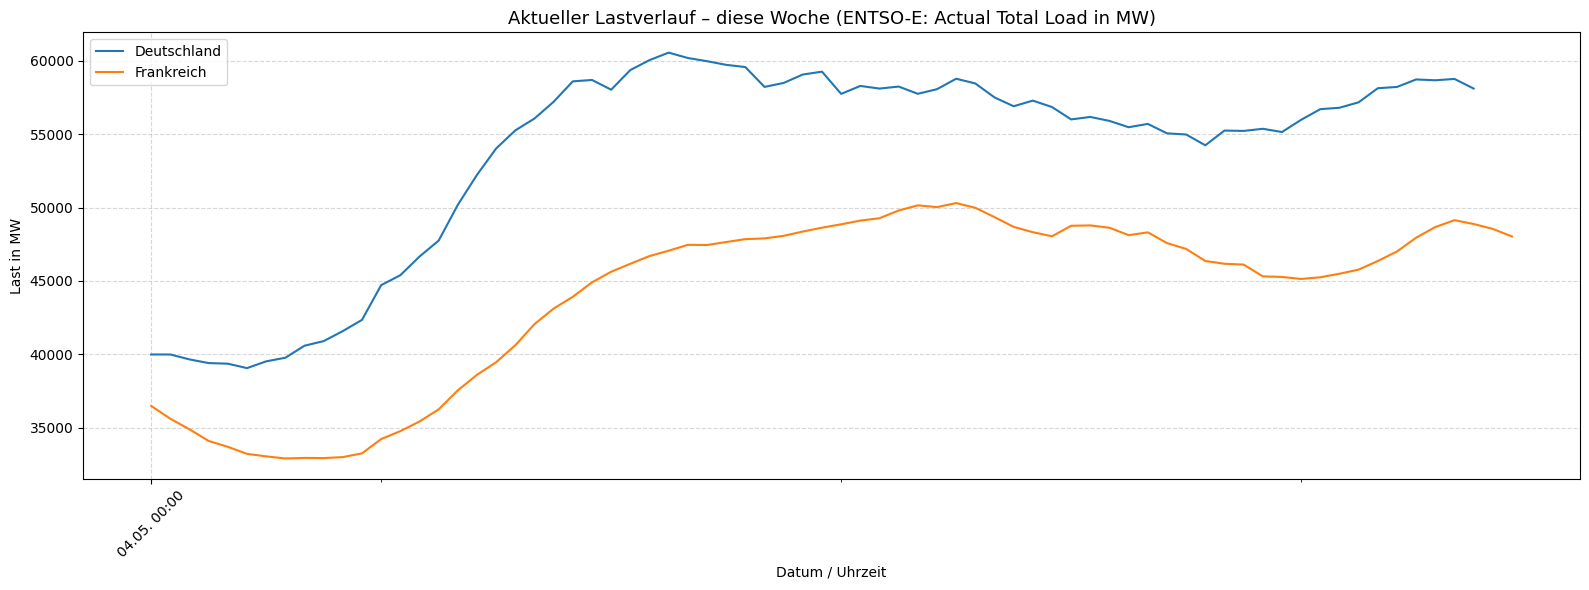

In [ ]:
# Erstelle Ordner für aktuelle Daten mit Prefix "Diagramme_"
os.makedirs("Diagramme_aktuell", exist_ok=True)

# Erstelle Liniendiagramm für die aktuelle Woche mit Uhrzeiten
fig, ax = plt.subplots(figsize=(16, 6))

# Zeichne für jedes Land eine Linie
for land in df_woche.columns:  # df_woche wurde in vorheriger Zelle geladen
    ax.plot(df_woche.index, df_woche[land], label=land)

# Beschriftungen
ax.set_title("Aktueller Lastverlauf – diese Woche (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

# Automatische Tick-Platzierung für Datums-/Uhrzeitleisten
ax.xaxis.set_major_locator(mdates.DayLocator())  # Hauptticks: jeden Tag
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m."))  # Format: "04.05." (Tag.Monat)
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))  # Nebenticks: alle 6 Stunden
# Formatiere X-Achse mit Datum UND Uhrzeit
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m. %H:%M"))

plt.xticks(rotation=45)  # Drehe Labels um 45° (sonst überlappen sie)
plt.tight_layout()
# Speichere in "Diagramme_aktuell/" Ordner
plt.savefig("Diagramme_aktuell/lastverlauf_woche.png", dpi=150)  # dpi=150 für bessere Qualität
plt.show()

In [ ]:
# Funktion: Lade VORHERIGER Monat (kompletter Monat: 1. bis 30./31.)
def lade_aktueller_monat(client, laender):
    """
    Lädt den stündlichen Lastverlauf des VORHERIGEN MONATS für alle Länder.
    Immer vollständig: vom 1. bis zum letzten Tag des Vormonats.
    """
    # Hole aktuelle Zeit
    jetzt = pd.Timestamp.now(tz="UTC")
    
    # Berechne 1. des aktuellen Monats
    monatsbeginn_aktuell = jetzt.normalize().replace(day=1)
    
    # Der Vormonat beginnt am 1. des Vormonats
    monatsbeginn = (monatsbeginn_aktuell - pd.Timedelta(days=1)).replace(day=1)
    # Der Vormonat endet am 1. des aktuellen Monats (exklusiv)
    monatsende = monatsbeginn_aktuell

    monatsdaten_aktuell = {}
    for land, kuerzel in laender.items():
        try:
            # Hole stündliche Lastdaten für den kompletten Vormonat
            daten = hole_load_daten(client, kuerzel, monatsbeginn, monatsende)
            # Konvertiere zu Series falls nötig
            if hasattr(daten, 'squeeze'):
                daten = daten.squeeze()
            monatsdaten_aktuell[land] = daten
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    # Kombiniere zu DataFrame
    df = pd.concat(monatsdaten_aktuell, axis=1)
    df.columns = monatsdaten_aktuell.keys()
    return df

=== Aktueller Monat ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


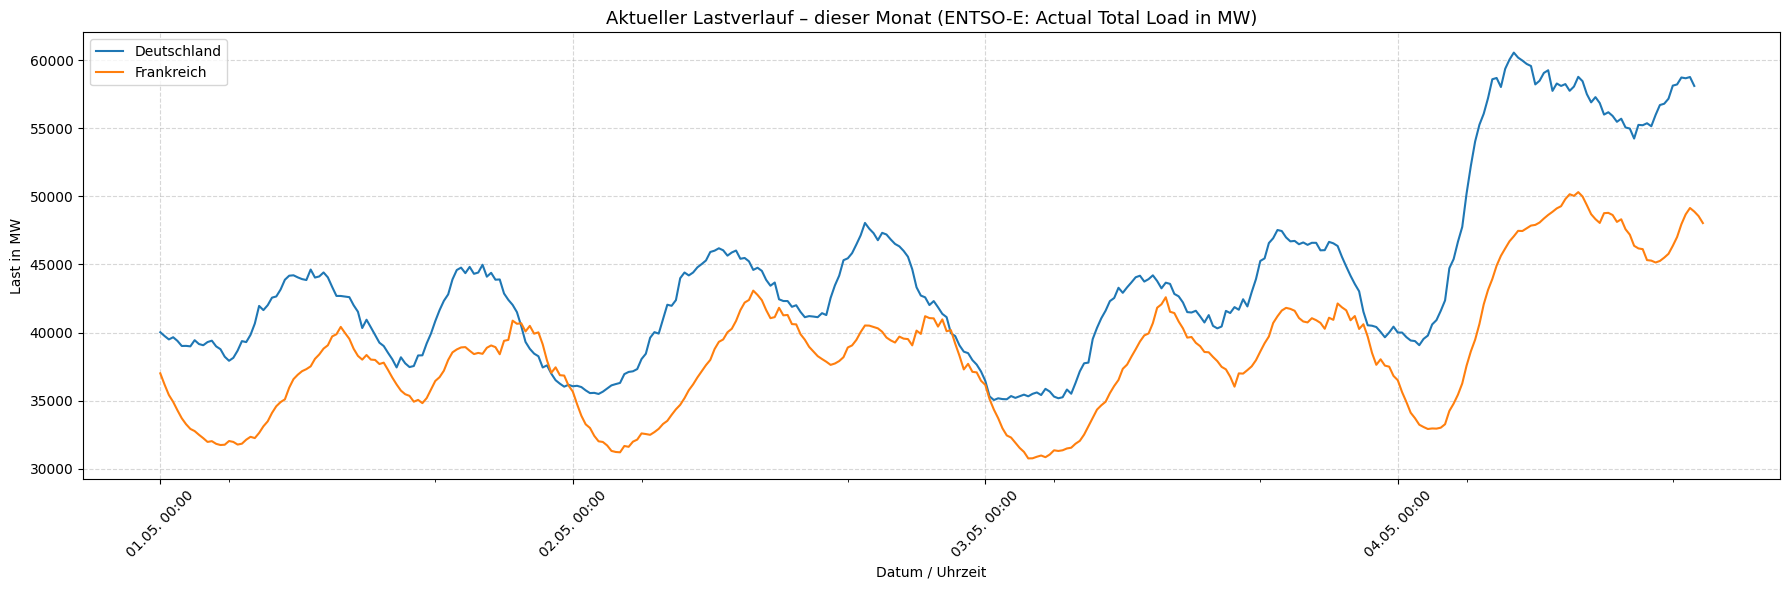

In [ ]:
print("=== Aktueller Monat ===")
# Lade Lastdaten für den aktuellen Monat (von Zelle weiter oben)
df_monat_aktuell = lade_aktueller_monat(client, laender)

# Erstelle Ordner für aktuelle Daten mit Prefix "Diagramme_"
os.makedirs("Diagramme_aktuell", exist_ok=True)

# Erstelle Liniendiagramm für den aktuellen Monat mit Uhrzeiten
fig, ax = plt.subplots(figsize=(18, 6))

# Zeichne für jedes Land eine Linie
for land in df_monat_aktuell.columns:
    ax.plot(df_monat_aktuell.index, df_monat_aktuell[land], label=land)

# Beschriftungen
ax.set_title("Aktueller Lastverlauf – dieser Monat (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

# Automatische Tick-Platzierung für Datums-/Uhrzeitleisten
ax.xaxis.set_major_locator(mdates.DayLocator())  # Hauptticks: jeden Tag
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m. %H:%M"))  # Format: Datum + Uhrzeit
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=12))  # Nebenticks: alle 12 Stunden

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Diagramme_aktuell/lastverlauf_monat.png", dpi=150)
plt.show()

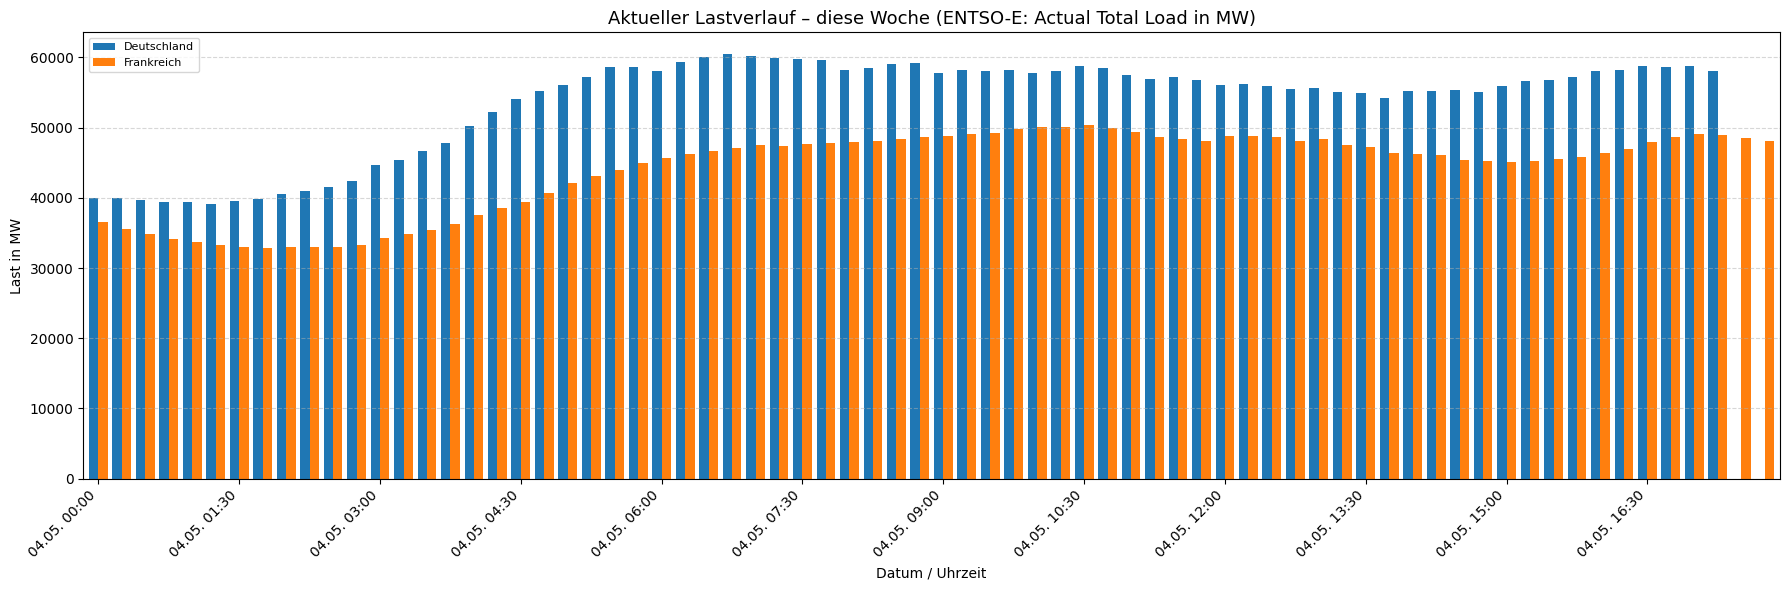

In [ ]:
# Erstelle Ordner für aktuelle Daten mit Prefix "Diagramme_"
os.makedirs("Diagramme_aktuell", exist_ok=True)

# Erstelle Balkendiagramm für die aktuelle Woche mit Uhrzeiten
fig, ax = plt.subplots(figsize=(18, 6))  # Etwas breiter für mehr X-Labels

# Zeichne Balkendiagramm (jeder Balken = eine Stunde für ein Land)
df_woche.plot(kind="bar", ax=ax, edgecolor="none", width=0.8)

# Beschriftungen
ax.set_title("Aktueller Lastverlauf – diese Woche (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend(fontsize=8)  # Kleine Schrift für Legende (viele Länder)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# X-Achse mit mehr Uhrzeitlabels: zeige alle 6 Stunden statt nur Tage
ticks = range(0, len(df_woche), 6)  # Alle 6 Stunden ein Label
ax.set_xticks(ticks)
# Formatiere Labels mit Datum UND Uhrzeit
ax.set_xticklabels([df_woche.index[i].strftime("%d.%m. %H:%M") for i in ticks], rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Diagramme_aktuell/lastverlauf_balken_woche.png", dpi=150)
plt.show()

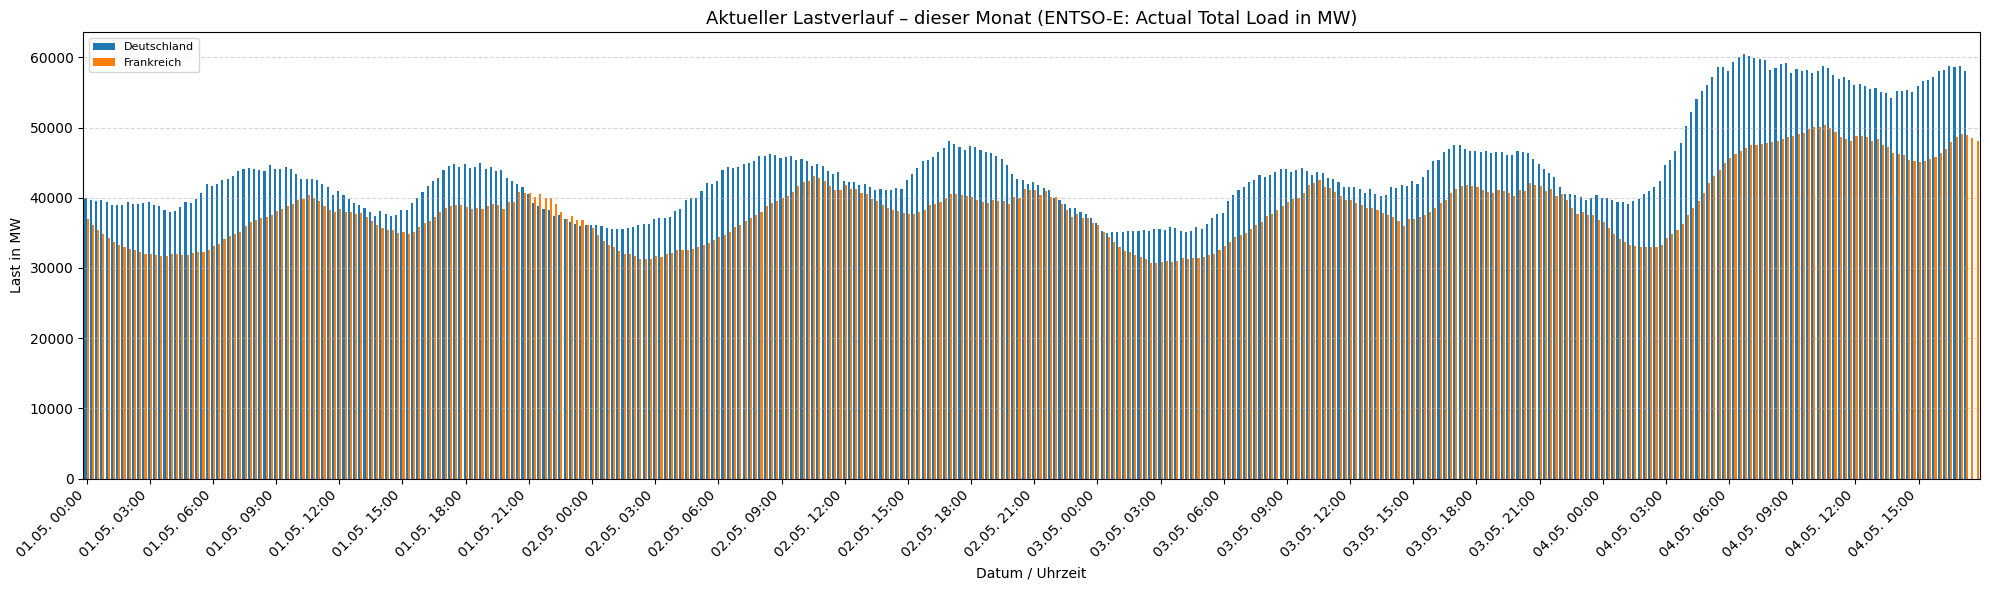

In [ ]:
# Erstelle Ordner für aktuelle Daten mit Prefix "Diagramme_"
os.makedirs("Diagramme_aktuell", exist_ok=True)

# Erstelle Balkendiagramm für den aktuellen Monat mit Uhrzeiten
fig, ax = plt.subplots(figsize=(20, 6))  # Noch breiter wegen mehr Datenpunkte

# Zeichne Balkendiagramm (jeder Balken = eine Stunde)
df_monat_aktuell.plot(kind="bar", ax=ax, edgecolor="none", width=0.8)

# Beschriftungen
ax.set_title("Aktueller Lastverlauf – dieser Monat (ENTSO-E: Actual Total Load in MW)", fontsize=13)
ax.set_xlabel("Datum / Uhrzeit")
ax.set_ylabel("Last in MW")
ax.legend(fontsize=8)  # Kleine Schrift für Legende
ax.grid(axis="y", linestyle="--", alpha=0.5)

# X-Achse mit Uhrzeitlabels: zeige alle 12 Stunden ein Label (wegen großer Menge an Daten)
ticks = range(0, len(df_monat_aktuell), 12)  # Alle 12 Stunden
ax.set_xticks(ticks)
# Formatiere Labels mit Datum UND Uhrzeit
ax.set_xticklabels([df_monat_aktuell.index[i].strftime("%d.%m. %H:%M") for i in ticks], rotation=45, ha='right')

plt.tight_layout()
plt.savefig("Diagramme_aktuell/lastverlauf_balken_monat.png", dpi=150)
plt.show()

In [ ]:
def lade_generation_woche(client, laender):
    """
    Lädt die gesamte Stromerzeugung der VORHERIGEN WOCHE für alle Länder.
    Immer vollständig: von Montag bis Sonntag (7 Tage komplett)
    """
    # Hole aktuelle Zeit
    jetzt = pd.Timestamp.now(tz="UTC")
    
    # Berechne Montag dieser Woche
    montag_diese_woche = jetzt.normalize() - pd.Timedelta(days=jetzt.weekday())
    
    # Berechne Montag und Sonntag der VORHERIGEN Woche
    wochenbeginn = montag_diese_woche - pd.Timedelta(days=7)  # Montag der Woche davor
    wochenende = wochenbeginn + pd.Timedelta(days=7)  # Montag der aktuellen Woche (= Sonntag+1)

    generationdaten = {}
    for land, kuerzel in laender.items():
        try:
            daten = hole_generation_daten(client, kuerzel, wochenbeginn, wochenende)
            # Alle Erzeugungsarten summieren
            gesamt = daten.sum(axis=1)
            generationdaten[land] = gesamt
            print(f"{land}: Daten geladen ✅")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    df = pd.concat(generationdaten, axis=1)
    df.columns = generationdaten.keys()
    return df

In [82]:
print("=== Last aktuelle Woche ===")
df_woche = lade_aktuelle_woche(client, laender)

print("\n=== Generation aktuelle Woche ===")
df_gen_woche = lade_generation_woche(client, laender)

=== Last aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅

=== Generation aktuelle Woche ===
Deutschland: Daten geladen ✅
Frankreich: Daten geladen ✅


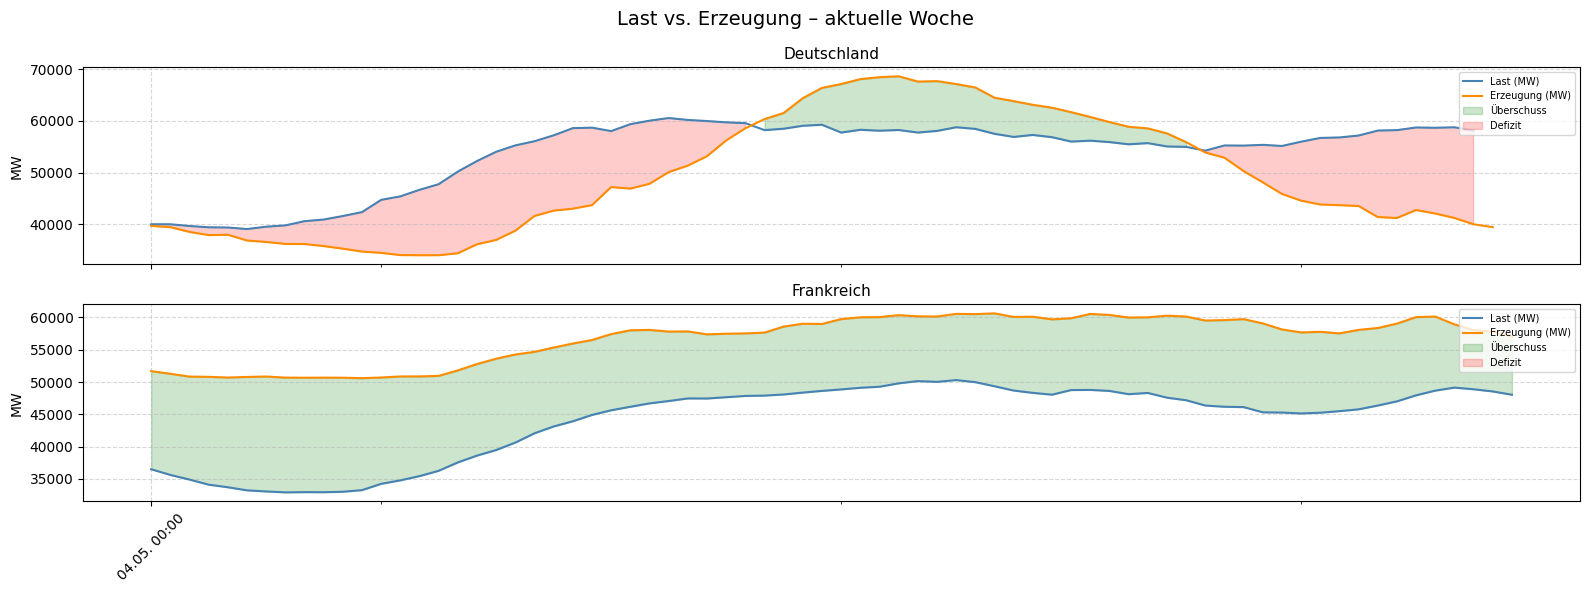

In [ ]:
# Erstelle Ordner für aktuelle Daten mit Prefix "Diagramme_"
os.makedirs("Diagramme_aktuell", exist_ok=True)

# Erstelle mehrere Subplots (ein Plot pro Land) mit Uhrzeiten
fig, axes = plt.subplots(len(laender), 1, figsize=(16, len(laender) * 3), sharex=True)
# axes = Array von Achsen-Objekten (eine für jedes Land)

# Schleife über alle Länder
for ax, land in zip(axes, laender.keys()):
    if land in df_woche.columns and land in df_gen_woche.columns:
        # Hole Last und Erzeugung für dieses Land
        last_series = df_woche[land]
        # Gleiche Indizes ab (beide müssen gleiche Zeitstempel haben)
        gen_series = df_gen_woche[land].reindex(last_series.index, method='nearest')
        
        # Zeichne zwei Linien: Last (blau) und Erzeugung (orange)
        ax.plot(last_series.index, last_series, label="Last (MW)", color="steelblue")
        ax.plot(gen_series.index, gen_series, label="Erzeugung (MW)", color="darkorange")
        
        # Fülle Bereiche zwischen den Kurven
        # Grün wenn Erzeugung >= Last (Überschuss)
        ax.fill_between(last_series.index, last_series, gen_series,
                        where=gen_series >= last_series,
                        alpha=0.2, color="green", label="Überschuss")
        # Rot wenn Erzeugung < Last (Defizit = braucht Import)
        ax.fill_between(last_series.index, last_series, gen_series,
                        where=gen_series < last_series,
                        alpha=0.2, color="red", label="Defizit")
        
        # Beschriftungen für dieses Subplot
        ax.set_title(land, fontsize=11)
        ax.set_ylabel("MW")
        ax.legend(loc="upper right", fontsize=7)
        ax.grid(linestyle="--", alpha=0.5)
        
        # Formatiere X-Achsen-Labels mit Uhrzeiten
        ax.xaxis.set_major_locator(mdates.DayLocator())  # Jeden Tag
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m. %H:%M"))  # Datum + Uhrzeit
        ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))  # Alle 6 Stunden

# Haupttitel über alle Subplots
plt.suptitle("Last vs. Erzeugung – aktuelle Woche", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Diagramme_aktuell/last_vs_generation_woche.png", dpi=150)
plt.show()

=== Anteil Erneuerbare 2023 ===
Deutschland: 53.75% erneuerbar
Frankreich: 25.56% erneuerbar


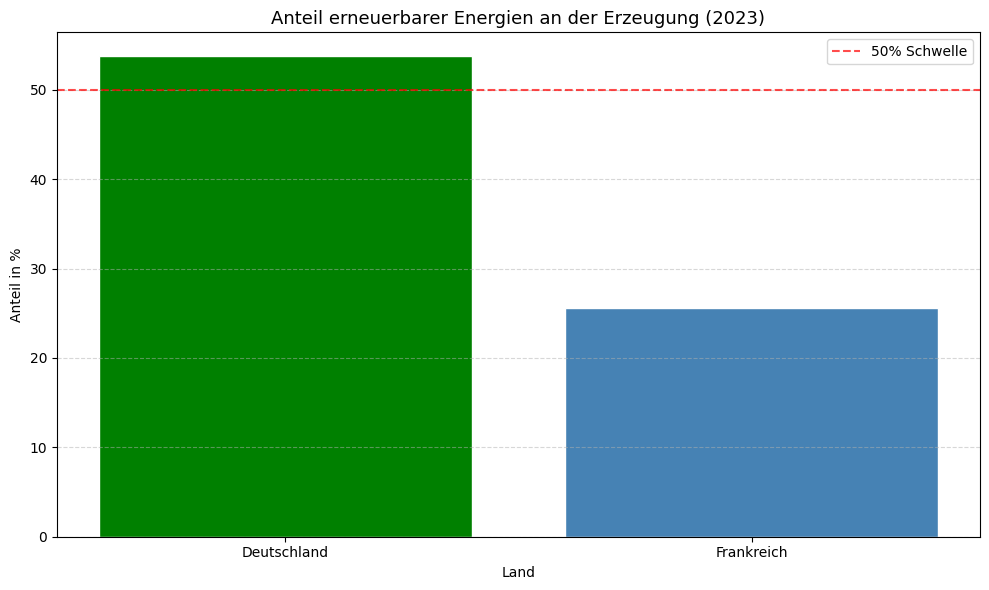

In [84]:
# Funktion: Berechne Anteil erneuerbarer Energien
def lade_erneuerbare(client, laender, jahr):
    """
    Berechnet für jedes Land: % der Erzeugung aus erneuerbaren Energien
    """
    # Definiere Zeitraum für das ganze Jahr
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")

    # Liste der erneuerbaren Energietypen (wie ENTSO-E sie nennt)
    erneuerbare_typen = [
        "Solar", "Wind Onshore", "Wind Offshore",
        "Hydro Run-of-river and poundage", "Hydro Water Reservoir",
        "Geothermal", "Biomass"
    ]

    ergebnis = {}
    for land, kuerzel in laender.items():
        try:
            # Hole Erzeugungsdaten (alle Energiearten)
            daten = hole_generation_daten(client, kuerzel, start, end)
            # Vereinfache Multi-Index Spalten (pandas-technisch)
            if isinstance(daten.columns, pd.MultiIndex):
                daten.columns = daten.columns.get_level_values(0)
            
            # Berechne Gesamterzeugung (summe aller Energiearten)
            gesamt = daten.sum(axis=1).sum()  # axis=1 = über Energiearten, dann über Zeit
            # Berechne nur Erzeugung aus erneuerbaren (die in der Liste sind)
            erneuerbar = daten[[s for s in erneuerbare_typen if s in daten.columns]].sum(axis=1).sum()
            # Berechne Prozentanteil: (erneuerbar / gesamt) * 100
            ergebnis[land] = round((erneuerbar / gesamt) * 100, 2)
            print(f"{land}: {ergebnis[land]}% erneuerbar")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    # Gebe Ergebnis als pandas Series zurück (sortiert absteigend)
    return pd.Series(ergebnis).sort_values(ascending=False)

# Lade und visualisiere Erneuerbare für 2023
print("=== Anteil Erneuerbare 2023 ===")
erneuerbare_2023 = lade_erneuerbare(client, laender, 2023)

# Erstelle Balkendiagramm
fig, ax = plt.subplots(figsize=(10, 6))
# Färbe grün (über 50%) oder blau (unter 50%)
farben = ["green" if v >= 50 else "steelblue" for v in erneuerbare_2023.values]
ax.bar(erneuerbare_2023.index, erneuerbare_2023.values, color=farben, edgecolor="white")
ax.axhline(50, color="red", linestyle="--", alpha=0.7, label="50% Schwelle")  # Referenzlinie
ax.set_title("Anteil erneuerbarer Energien an der Erzeugung (2023)", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Anteil in %")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("erneuerbare_anteil_2023.png")
plt.show()

=== Lastdeckungsgrad 2023 ===
Deutschland: 101.71% Lastdeckungsgrad
Frankreich: 113.55% Lastdeckungsgrad


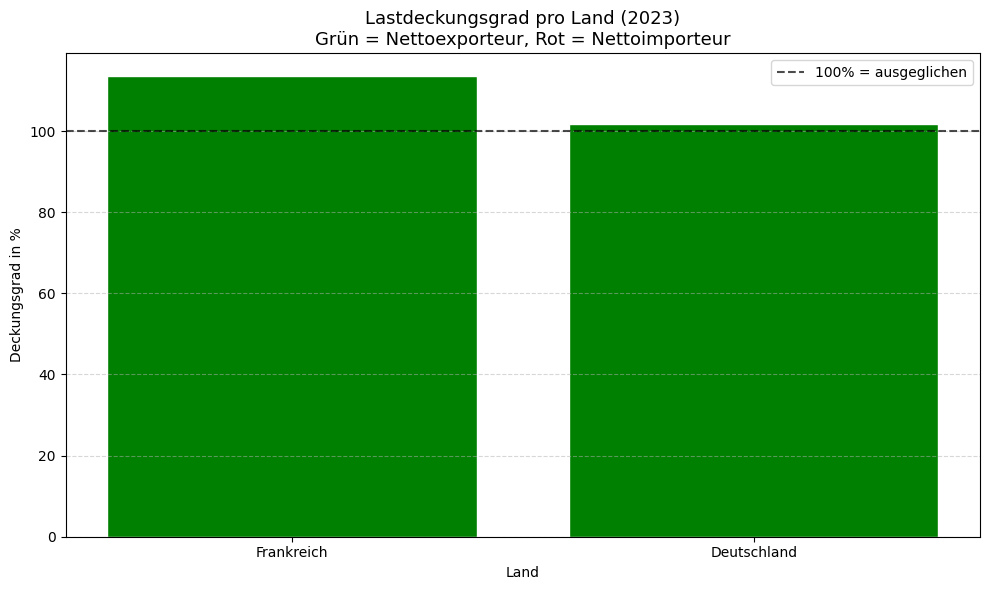

In [85]:
# Funktion: Berechne Lastdeckungsgrad (Erzeugung / Last)
def berechne_lastdeckungsgrad(client, laender, jahr):
    """
    Verhältnis Erzeugung / Last pro Land
    Über 100% = Nettoexporteur (erzeugt mehr als es braucht)
    Unter 100% = Nettoimporteur (braucht Strom von außen)
    """
    # Definiere Zeitraum
    start = pd.Timestamp(f"{jahr}-01-01", tz="UTC")
    end   = pd.Timestamp(f"{jahr+1}-01-01", tz="UTC")

    ergebnis = {}
    for land, kuerzel in laender.items():
        try:
            # Hole Last und Erzeugungsdaten
            last_daten = hole_load_daten(client, kuerzel, start, end)
            gen = hole_generation_daten(client, kuerzel, start, end)
            
            # Vereinfache Multi-Index Spalten falls nötig
            if isinstance(gen.columns, pd.MultiIndex):
                gen.columns = gen.columns.get_level_values(0)

            # Berechne Gesamtlast für das Jahr
            if isinstance(last_daten, pd.DataFrame):
                last = last_daten.sum().sum()  # Summe aller Spalten, dann aller Zeilen
            else:
                last = last_daten.sum()  # Falls schon ein Series

            # Berechne Gesamterzeugung für das Jahr
            if isinstance(gen, pd.DataFrame):
                erzeugung = gen.sum(axis=1).sum()
            else:
                erzeugung = gen.sum()

            # Konvertiere zu Zahl falls nötig (.item() extrahiert Wert aus Objekt)
            if hasattr(last, 'item'):
                last = last.item()
            
            # Sicherheitscheck: Keine Division durch Null
            if last == 0:
                raise ZeroDivisionError("Last ist 0, Lastdeckungsgrad kann nicht berechnet werden")

            # Berechne Prozentanteil: (Erzeugung / Last) * 100
            ergebnis[land] = round((erzeugung / last) * 100, 2)
            print(f"{land}: {ergebnis[land]}% Lastdeckungsgrad")
        except Exception as e:
            print(f"{land}: Fehler – {e}")

    # Gebe Ergebnis sortiert zurück (höchste zuerst)
    return pd.Series(ergebnis).sort_values(ascending=False)

# Berechne für 2023
print("=== Lastdeckungsgrad 2023 ===")
deckungsgrad = berechne_lastdeckungsgrad(client, laender, 2023)

# Visualisiere: Grün (über 100%) = Exporteur, Rot (unter 100%) = Importeur
fig, ax = plt.subplots(figsize=(10, 6))
farben = ["green" if v >= 100 else "tomato" for v in deckungsgrad.values]
ax.bar(deckungsgrad.index, deckungsgrad.values, color=farben, edgecolor="white")
ax.axhline(100, color="black", linestyle="--", alpha=0.7, label="100% = ausgeglichen")  # Referenzlinie
ax.set_title("Lastdeckungsgrad pro Land (2023)\nGrün = Nettoexporteur, Rot = Nettoimporteur", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Deckungsgrad in %")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("lastdeckungsgrad_2023.png")
plt.show()

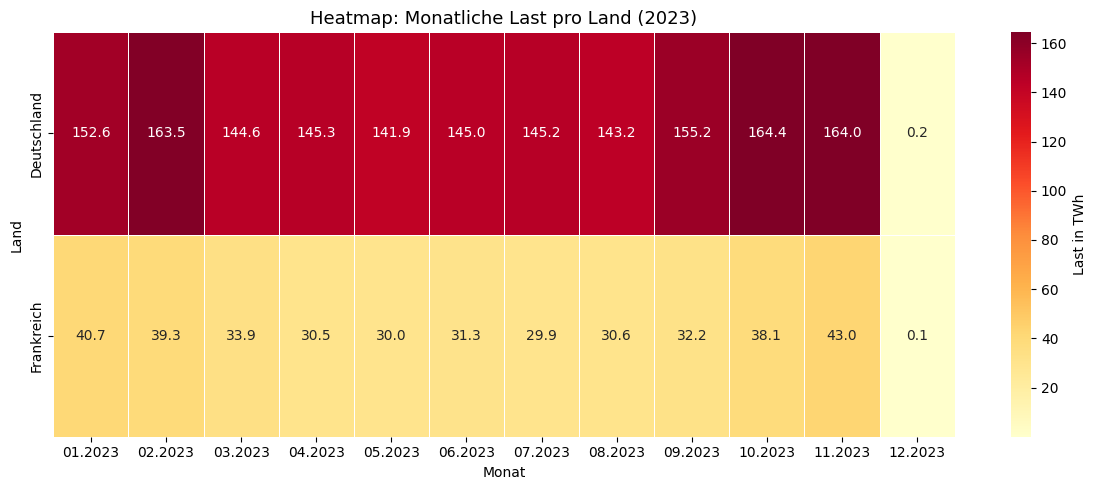

In [86]:
# Importiere seaborn - Bibliothek für schönere statistische Plots
import seaborn as sns

# Erstelle eine Heatmap (Wärmekarte) für 2023
fig, ax = plt.subplots(figsize=(12, 5))

# Transponiere df_2023: Länder als Zeilen, Monate als Spalten (bessere Sichtbarkeit)
sns.heatmap(
    df_2023.T,  # T = Transpose (umdrehen/wechseln)
    annot=True,  # annot=True: Zeige Zahlenwerte in den Zellen
    fmt=".1f",  # Formatiere auf 1 Dezimalstelle
    cmap="YlOrRd",  # Farbschema: Gelb (niedrig) bis Rot (hoch)
    linewidths=0.5,  # Dünne Linien zwischen den Zellen
    ax=ax,  # Zeichne auf unsere Achse
    cbar_kws={"label": "Last in TWh"}  # Beschriftung der Farblegende
)

# Beschriftungen
ax.set_title("Heatmap: Monatliche Last pro Land (2023)", fontsize=13)
ax.set_xlabel("Monat")  # Monats-Nummern (01, 02, ... 12)
ax.set_ylabel("Land")  # Ländernamen
plt.tight_layout()
plt.savefig("heatmap_2023.png")
plt.show()

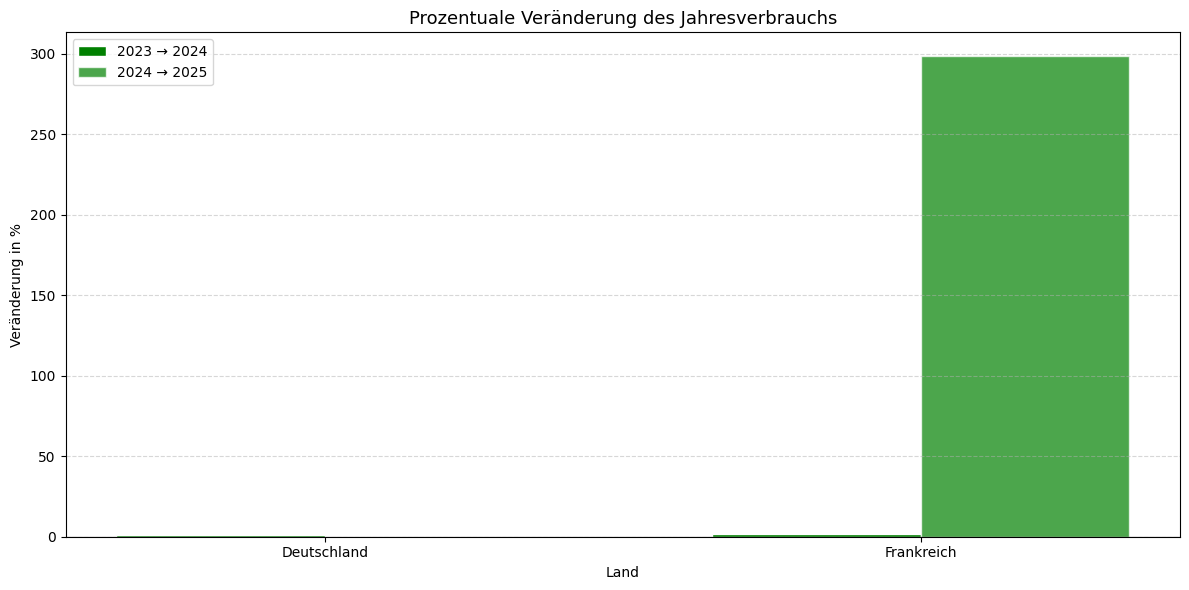

In [ ]:
# Erstelle Ordner für Vergleichsanalysen mit Prefix "Diagramme_"
os.makedirs("Diagramme_vergleich", exist_ok=True)

# Funktion: Berechne prozentuale Veränderung zwischen zwei Jahren
def berechne_veraenderung(df_vorjahr, df_aktuell):
    """
    Vergleicht zwei Jahre: ((aktuell - vorjahr) / vorjahr) * 100
    Positiv = Steigerung, Negativ = Rückgang
    """
    # Summiere Last pro Land für jedes Jahr
    gesamt_vorjahr  = df_vorjahr.sum()  # Summe aller Monate pro Land
    gesamt_aktuell  = df_aktuell.sum()
    # Berechne prozentuale Veränderung
    veraenderung    = ((gesamt_aktuell - gesamt_vorjahr) / gesamt_vorjahr) * 100
    return veraenderung.round(2)  # Runde auf 2 Dezimalstellen

# Berechne Veränderungen
veraenderung_23_24 = berechne_veraenderung(df_2023, df_2024)  # 2023 zu 2024
veraenderung_24_25 = berechne_veraenderung(df_2024, df_2025)  # 2024 zu 2025

# Erstelle Balkendiagramm zum Vergleich
fig, ax = plt.subplots(figsize=(12, 6))

# Definiere X-Positionen für die Balken
x = range(len(laender))
breite = 0.35  # Breite jedes Balkens

# Zeichne erste Balkengruppe (2023→2024) - links
balken1 = ax.bar([i - breite/2 for i in x], veraenderung_23_24.values,
                  breite, label="2023 → 2024",
                  # Färbe grün (positive Veränderung) oder rot (Rückgang)
                  color=["green" if v >= 0 else "tomato" for v in veraenderung_23_24.values],
                  edgecolor="white")
# Zeichne zweite Balkengruppe (2024→2025) - rechts
balken2 = ax.bar([i + breite/2 for i in x], veraenderung_24_25.values,
                  breite, label="2024 → 2025",
                  color=["green" if v >= 0 else "tomato" for v in veraenderung_24_25.values],
                  edgecolor="white", alpha=0.7)

# Zeichne horizontale Linie bei 0% (keine Veränderung)
ax.axhline(0, color="black", linewidth=0.8)

# Beschriftungen
ax.set_xticks(list(x))
ax.set_xticklabels(laender.keys())  # Ländernamen als X-Labels
ax.set_title("Prozentuale Veränderung des Jahresverbrauchs", fontsize=13)
ax.set_xlabel("Land")
ax.set_ylabel("Veränderung in %")
ax.legend()  # Zeige Legende (welche Farbe = welches Jahr)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
# Speichere im neuen Vergleichsordner
plt.savefig("Diagramme_vergleich/jahresveraenderung.png")
plt.show()

In [ ]:
print("=== Anteil Erneuerbare ===")

# Schleife: Erstelle für jedes Jahr (2023, 2024, 2025) ein separates Diagramm
for jahr in [2023, 2024, 2025]:
    # Erstelle Ordner für das Jahr mit Prefix "Diagramme_"
    os.makedirs(f"Diagramme_{jahr}", exist_ok=True)
    
    print(f"\nGeneriere Diagramm für {jahr}...")
    # Berechne Erneuerbaren-Anteil für dieses Jahr
    erneuerbare = lade_erneuerbare(client, laender, jahr)
    
    # Erstelle Balkendiagramm
    fig, ax = plt.subplots(figsize=(12, 6))
    # Zeichne Balken in Blau
    erneuerbare.plot(kind="bar", ax=ax, edgecolor="white", color="steelblue")
    # Zeichne rote Referenzlinie bei 50%
    ax.axhline(50, color="red", linestyle="--", alpha=0.7, linewidth=2, label="50% Schwelle")
    ax.set_title(f"Anteil erneuerbarer Energien an der Erzeugung ({jahr})", fontsize=13)
    ax.set_xlabel("Land")
    ax.set_ylabel("Anteil in %")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_ylim(0, 120)  # Setze Y-Achse 0-120%
    plt.xticks(rotation=45)
    plt.tight_layout()
    # Speichere im Jahr-Ordner
    plt.savefig(f"Diagramme_{jahr}/erneuerbare_anteil.png")
    plt.close()  # Gib Speicher frei

print("✅ Erneuerbare-Anteile für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

=== Anteil Erneuerbare ===

Generiere Diagramm für 2023...
Deutschland: 53.75% erneuerbar
Frankreich: 25.56% erneuerbar

Generiere Diagramm für 2024...
Deutschland: 56.65% erneuerbar
Frankreich: 25.23% erneuerbar

Generiere Diagramm für 2025...
Deutschland: 57.04% erneuerbar
Frankreich: 24.57% erneuerbar
✅ Erneuerbare-Anteile für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [ ]:
print("=== Lastdeckungsgrad ===")

# Schleife: Erstelle für jedes Jahr ein separates Diagramm
for jahr in [2023, 2024, 2025]:
    # Erstelle Ordner für das Jahr mit Prefix "Diagramme_"
    os.makedirs(f"Diagramme_{jahr}", exist_ok=True)
    
    print(f"\nGeneriere Diagramm für {jahr}...")
    # Berechne Lastdeckungsgrad für dieses Jahr
    deckungsgrad = berechne_lastdeckungsgrad(client, laender, jahr)
    
    # Erstelle Balkendiagramm
    fig, ax = plt.subplots(figsize=(12, 6))
    # Zeichne Balken in Dunkelgrün
    deckungsgrad.plot(kind="bar", ax=ax, edgecolor="white", color="darkgreen")
    # Zeichne schwarze Referenzlinie bei 100%
    ax.axhline(100, color="black", linestyle="--", alpha=0.7, linewidth=2, label="100% = ausgeglichen")
    ax.set_title(f"Lastdeckungsgrad pro Land ({jahr})\nÜber 100% = Nettoexporteur", fontsize=13)
    ax.set_xlabel("Land")
    ax.set_ylabel("Deckungsgrad in %")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    # Speichere im Jahr-Ordner
    plt.savefig(f"Diagramme_{jahr}/deckungsgrad.png")
    plt.close()  # Gib Speicher frei

print("✅ Lastdeckungsgrad für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

=== Lastdeckungsgrad ===

Generiere Diagramm für 2023...
Deutschland: 101.71% Lastdeckungsgrad
Frankreich: 113.55% Lastdeckungsgrad

Generiere Diagramm für 2024...
Deutschland: 96.82% Lastdeckungsgrad
Frankreich: 136.84% Lastdeckungsgrad

Generiere Diagramm für 2025...
Deutschland: 96.74% Lastdeckungsgrad
Frankreich: 124.74% Lastdeckungsgrad
✅ Lastdeckungsgrad für 2023, 2024, 2025 in separaten Ordnern abgespeichert


In [ ]:
# Importiere seaborn für Heatmaps (Wärmekarten)
import seaborn as sns

# Dictionary mit den drei Jahren
jahre_dict = {"2023": df_2023, "2024": df_2024, "2025": df_2025}

# Schleife: Erstelle für jedes Jahr eine separate Heatmap
for jahr, df in jahre_dict.items():
    # Erstelle Ordner für das Jahr mit Prefix "Diagramme_"
    os.makedirs(f"Diagramme_{jahr}", exist_ok=True)
    
    # Erstelle neue Figur für Heatmap
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Erstelle Heatmap: Transponiere die Daten (Länder als Zeilen, Monate als Spalten)
    sns.heatmap(
        df.T,  # T = Transpose (umdrehen)
        annot=True,  # annot=True: Zeige Zahlen in den Zellen
        fmt=".1f",  # Formatiere Zahlen auf 1 Dezimalstelle
        cmap="YlOrRd",  # Farbschema: Gelb-Orange-Rot (hellgelb = niedrig, dunkelrot = hoch)
        linewidths=0.5,  # Zeichne dünne Linien zwischen Zellen
        ax=ax,  # Zeichne auf unsere Achse
        cbar_kws={"label": "Last in TWh"}  # Beschriftung der Farbbalken-Legende
    )
    
    # Beschriftungen
    ax.set_title(f"Heatmap: Monatliche Last pro Land ({jahr})", fontsize=13)
    ax.set_xlabel("Monat")  # X-Achse
    ax.set_ylabel("Land")  # Y-Achse
    
    plt.tight_layout()
    # Speichere im Jahr-Ordner
    plt.savefig(f"Diagramme_{jahr}/heatmap.png")
    plt.close()  # Gib Speicher frei

print("✅ Heatmaps für 2023, 2024, 2025 in separaten Ordnern abgespeichert")

✅ Heatmaps für 2023, 2024, 2025 in separaten Ordnern abgespeichert
